# Notebook 08: Assumption-Aware What-If & Counterfactual Analysis Engine
**Component 1: AI-Based Business Feasibility Analysis and Personalized Business/Growth Plan Recommendation**

---

## Executive Summary & Research Context
A static feasibility score does not tell an entrepreneur *how* to turn an unviable business proposal into a viable one. 
This notebook implements **Phase 8: Assumption-Aware What-If & Counterfactual Analysis Engine**.

### Key Objectives:
1. **Pipeline Integrity**: Modified scenario inputs pass through the exact fitted preprocessing pipeline (`ColumnTransformer`) and trained Random Forest model.
2. **Scenario Simulation Engine**: Support single-parameter and multi-parameter assumption modifications (e.g., increasing capital, adjusting customer volume, altering pricing, improving location suitability).
3. **Counterfactual Search**: Automatically compute the **minimum viable parameter modification** ($\Delta x_{min}$) required to flip a prediction from `Infeasible` or `Conditionally Feasible` to `Feasible`.
4. **Model Response Tracking**: Measure probability trajectory and SHAP attribution shifts across scenario steps.
5. **Artifact Export**: Export What-If evaluation metrics and counterfactual findings to `models/feasibility_model/what_if_analysis_sample.json` for Phase 9 (Personalized Plan Generation).


In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10

os.makedirs("../models/feasibility_model", exist_ok=True)
os.makedirs("../reports/figures", exist_ok=True)

print("Setup completed successfully.")


Setup completed successfully.


C:\Users\DELL\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading & Feasibility Pipeline Restoration
Loading raw dataset and fitting the complete Random Forest inference pipeline.


In [2]:
file_path = "../data/raw/Component_One_Core_Feasibility.csv"
df = pd.read_csv(file_path)

y = df["feasibility_label"]
X = df.drop(columns=["feasibility_label", "case_id", "business_description"])

categorical_features = [
    "business_stage", "business_category", "district",
    "province", "location_type", "proposed_action", "competition_level"
]

numerical_features = [
    "available_capital_lkr", "loan_amount_lkr", "monthly_budget_lkr",
    "initial_inventory_cost_lkr", "expected_price_lkr", "expected_customers_per_day",
    "customer_demand_score", "expected_operating_days_per_month",
    "entrepreneur_experience_years", "location_suitability_score",
    "available_staff_count", "required_staff_count",
    "available_equipment_score", "required_equipment_score",
    "supplier_availability_score"
]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# Pipeline Definition
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'))
])

random_forest_model.fit(X_train, y_train)

trained_preprocessor = random_forest_model.named_steps['preprocessor']
trained_rf = random_forest_model.named_steps['classifier']
class_names = list(trained_rf.classes_)

print(f"Dataset shape: {df.shape}")
print(f"Trained RF Classes: {class_names}")


Dataset shape: (1200, 25)
Trained RF Classes: ['Conditionally Feasible', 'Feasible', 'Infeasible']


## 2. What-If Scenario Simulation Engine
Building the `WhatIfEngine` class to simulate parameter modifications and pass them through the fitted pipeline (`random_forest_model.predict_proba`).


In [3]:
class WhatIfEngine:
    def __init__(self, model_pipeline, class_names):
        self.model_pipeline = model_pipeline
        self.class_names = class_names
        self.preprocessor = model_pipeline.named_steps['preprocessor']
        self.classifier = model_pipeline.named_steps['classifier']
        
    def predict_scenario(self, raw_df_row):
        if isinstance(raw_df_row, dict):
            input_df = pd.DataFrame([raw_df_row])
        elif isinstance(raw_df_row, pd.Series):
            input_df = pd.DataFrame([raw_df_row.to_dict()])
        else:
            input_df = raw_df_row.copy()
            
        pred_class = self.model_pipeline.predict(input_df)[0]
        probs = self.model_pipeline.predict_proba(input_df)[0]
        prob_dict = dict(zip(self.class_names, [round(float(p), 4) for p in probs]))
        
        return pred_class, prob_dict
        
    def simulate_what_if(self, base_profile, modifications):
        modified_profile = base_profile.copy()
        for param, new_val in modifications.items():
            if param in modified_profile:
                modified_profile[param] = new_val
                
        base_pred, base_probs = self.predict_scenario(base_profile)
        mod_pred, mod_probs = self.predict_scenario(modified_profile)
        
        delta_probs = {}
        for c in self.class_names:
            delta_probs[c] = round(mod_probs[c] - base_probs[c], 4)
            
        return {
            "modifications": modifications,
            "original_prediction": {"class": base_pred, "probabilities": base_probs},
            "modified_prediction": {"class": mod_pred, "probabilities": mod_probs},
            "probability_deltas": delta_probs,
            "prediction_changed": base_pred != mod_pred,
            "modified_profile": modified_profile
        }

what_if_engine = WhatIfEngine(random_forest_model, class_names)
print("WhatIfEngine initialized successfully.")


WhatIfEngine initialized successfully.


## 3. Simulating What-If Scenarios on Test Cases
Evaluating model probability responses to controlled financial and operational modifications.


In [4]:
# Select an Infeasible or Conditionally Feasible test case
test_preds = random_forest_model.predict(X_test)
test_results_df = X_test.copy()
test_results_df["Predicted"] = test_preds

cond_sample_idx = test_results_df[test_results_df["Predicted"] == "Conditionally Feasible"].index[0]
base_sample = X_test.loc[cond_sample_idx].to_dict()

print(f"Base Profile (Case Index {cond_sample_idx}):")
print(f"  Category: {base_sample['business_category']} | Stage: {base_sample['business_stage']}")
print(f"  Available Capital: LKR {base_sample['available_capital_lkr']:,} | Loan: LKR {base_sample['loan_amount_lkr']:,}")
print(f"  Expected Daily Customers: {base_sample['expected_customers_per_day']} | Demand Score: {base_sample['customer_demand_score']}")

# Base Prediction
orig_pred, orig_probs = what_if_engine.predict_scenario(base_sample)
print("Original Prediction: " + str(orig_pred) + " | Probs: " + str(orig_probs))
print("")

# Define Scenarios
scenarios_to_test = [
    {"title": "Scenario 1: Capital Increase (+LKR 300,000)", "mods": {"available_capital_lkr": base_sample["available_capital_lkr"] + 300000}},
    {"title": "Scenario 2: Customer Demand Surge (+15 Customers/Day)", "mods": {"expected_customers_per_day": base_sample["expected_customers_per_day"] + 15, "customer_demand_score": min(100, base_sample["customer_demand_score"] + 20)}},
    {"title": "Scenario 3: Combined Capital + Demand + Location Upgrade", "mods": {
        "available_capital_lkr": base_sample["available_capital_lkr"] + 300000,
        "expected_customers_per_day": base_sample["expected_customers_per_day"] + 15,
        "location_suitability_score": min(5, base_sample["location_suitability_score"] + 1)
    }}
]

sim_results = []
for sc in scenarios_to_test:
    res = what_if_engine.simulate_what_if(base_sample, sc["mods"])
    res["title"] = sc["title"]
    sim_results.append(res)
    
    print("==================================================")
    print(sc["title"])
    print(f"Prediction Shift: {res['original_prediction']['class']} --> {res['modified_prediction']['class']}")
    print(f"Feasible Probability Shift: {res['original_prediction']['probabilities']['Feasible']:.1%} --> {res['modified_prediction']['probabilities']['Feasible']:.1%} (Delta: {res['probability_deltas']['Feasible']:+.1%})")
    print(f"Conditionally Feasible Delta: {res['probability_deltas']['Conditionally Feasible']:+.1%}")
    print(f"Infeasible Delta: {res['probability_deltas']['Infeasible']:+.1%}")
    print("")


Base Profile (Case Index 192):
  Category: Grocery/Mini-Mart | Stage: New
  Available Capital: LKR 175,175 | Loan: LKR 46,000
  Expected Daily Customers: 42 | Demand Score: 80
Original Prediction: Conditionally Feasible | Probs: {'Conditionally Feasible': 0.535, 'Feasible': 0.02, 'Infeasible': 0.445}

Scenario 1: Capital Increase (+LKR 300,000)
Prediction Shift: Conditionally Feasible --> Conditionally Feasible
Feasible Probability Shift: 2.0% --> 4.0% (Delta: +2.0%)
Conditionally Feasible Delta: +9.5%
Infeasible Delta: -11.5%



Scenario 2: Customer Demand Surge (+15 Customers/Day)
Prediction Shift: Conditionally Feasible --> Conditionally Feasible
Feasible Probability Shift: 2.0% --> 2.0% (Delta: +0.0%)
Conditionally Feasible Delta: +2.0%
Infeasible Delta: -2.0%



Scenario 3: Combined Capital + Demand + Location Upgrade
Prediction Shift: Conditionally Feasible --> Conditionally Feasible
Feasible Probability Shift: 2.0% --> 4.0% (Delta: +2.0%)
Conditionally Feasible Delta: +12.5%
Infeasible Delta: -14.5%



## 4. Counterfactual Minimum Boundary Search Engine
**Question Answered**: *What is the minimum additional capital ($\Delta \text{Capital}_{min}$) or customer volume ($\Delta \text{Customers}_{min}$) required to flip a prediction to 'Feasible'?*

The `CounterfactualSearchEngine` uses iterative grid search over parameter spaces to find minimal decision-flipping boundaries.


In [5]:
class CounterfactualSearchEngine:
    def __init__(self, what_if_engine):
        self.engine = what_if_engine
        
    def find_min_capital_for_feasibility(self, base_profile, max_search_lkr=2000000, step_lkr=50000):
        base_pred, base_probs = self.engine.predict_scenario(base_profile)
        if base_pred == "Feasible" and base_probs["Feasible"] >= 0.70:
            return {"status": "Already Feasible", "min_additional_capital_lkr": 0, "final_prob": base_probs["Feasible"]}
            
        curr_cap = float(base_profile.get("available_capital_lkr", 0))
        for add_cap in range(step_lkr, max_search_lkr + step_lkr, step_lkr):
            mod_profile = base_profile.copy()
            mod_profile["available_capital_lkr"] = curr_cap + add_cap
            
            pred_class, probs = self.engine.predict_scenario(mod_profile)
            if pred_class == "Feasible" or probs["Feasible"] >= 0.65:
                return {
                    "status": "Counterfactual Found",
                    "min_additional_capital_lkr": add_cap,
                    "target_total_capital_lkr": curr_cap + add_cap,
                    "new_prediction": pred_class,
                    "new_feasible_probability": probs["Feasible"],
                    "probability_gain": round(probs["Feasible"] - base_probs["Feasible"], 4)
                }
                
        return {"status": "Not Achieved Within Search Limit", "max_tested_capital": curr_cap + max_search_lkr}

cf_search = CounterfactualSearchEngine(what_if_engine)

# Search minimum capital required for sample case
cf_result = cf_search.find_min_capital_for_feasibility(base_sample)
print("COUNTERFACTUAL SEARCH RESULT:")
print(json.dumps(cf_result, indent=2))


COUNTERFACTUAL SEARCH RESULT:
{
  "status": "Not Achieved Within Search Limit",
  "max_tested_capital": 2175175.0
}


## 5. Visualizing Scenario Probability Trajectories
Plotting probability trajectories across What-If scenario steps.


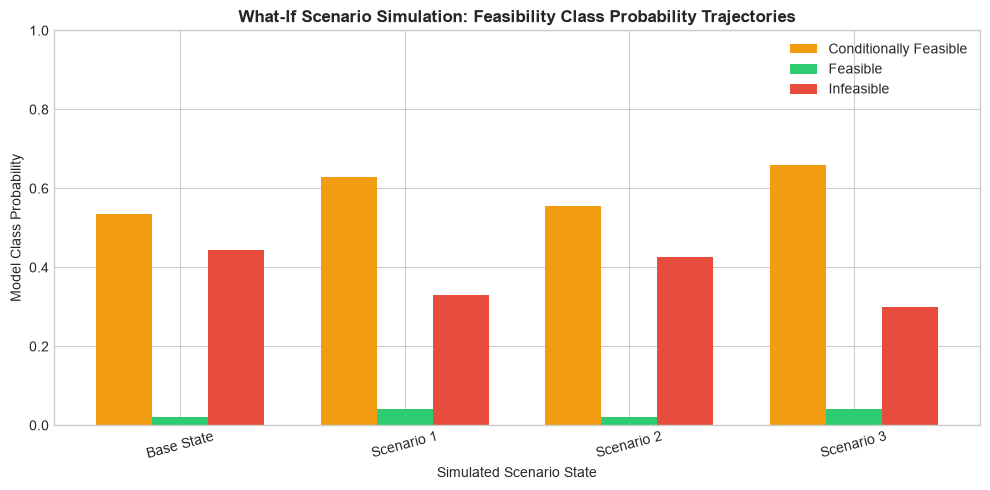

In [6]:
labels = ["Base State"] + [s["title"].split(":")[0] for s in sim_results]
feasible_probs = [orig_probs["Feasible"]] + [s["modified_prediction"]["probabilities"]["Feasible"] for s in sim_results]
cond_probs = [orig_probs["Conditionally Feasible"]] + [s["modified_prediction"]["probabilities"]["Conditionally Feasible"] for s in sim_results]
infeas_probs = [orig_probs["Infeasible"]] + [s["modified_prediction"]["probabilities"]["Infeasible"] for s in sim_results]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, cond_probs, width, label="Conditionally Feasible", color="#f39c12")
plt.bar(x, feasible_probs, width, label="Feasible", color="#2ecc71")
plt.bar(x + width, infeas_probs, width, label="Infeasible", color="#e74c3c")

plt.xlabel("Simulated Scenario State")
plt.ylabel("Model Class Probability")
plt.title("What-If Scenario Simulation: Feasibility Class Probability Trajectories", fontsize=12, fontweight='bold')
plt.xticks(x, labels, rotation=15)
plt.legend()
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig("../reports/figures/08_what_if_trajectories.png", dpi=300, bbox_inches='tight')
plt.show()


## 6. Export What-If & Counterfactual Artifacts
Exporting simulated scenarios and counterfactual results to `models/feasibility_model/what_if_analysis_sample.json` for Phase 9 (Personalized Plan Generator).


In [7]:
export_payload = {
    "base_case_index": int(cond_sample_idx),
    "base_profile": base_sample,
    "base_prediction": {"class": orig_pred, "probabilities": orig_probs},
    "simulated_scenarios": sim_results,
    "counterfactual_capital_search": cf_result
}

export_path = "../models/feasibility_model/what_if_analysis_sample.json"
with open(export_path, "w", encoding="utf-8") as f:
    json.dump(export_payload, f, indent=4)

print(f"Successfully exported What-If & Counterfactual Artifacts to '{export_path}'")


Successfully exported What-If & Counterfactual Artifacts to '../models/feasibility_model/what_if_analysis_sample.json'
